In [39]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR
from torch_geometric.data import Data
from torch_geometric.nn import RGCNConv
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('C:\\Users\\ekru\\Documents\\Cursor\\ganv2\\Project\\Dataset Creation\\Final_Graph.csv')
print(df.head())

                          Head        Relation           Tail
0       Fluocinolone acetonide  INTERACTS_WITH       Abetimus
1                   Tazarotene  INTERACTS_WITH     Oxybutynin
2                    Guanoclor  INTERACTS_WITH  Nortriptyline
3  Dexamethasone isonicotinate  INTERACTS_WITH    Oxaliplatin
4                 Sparfloxacin  INTERACTS_WITH   Iron sucrose


In [22]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [23]:
print("Train:")
print(train_df)
print("Test:")
print(test_df)
print("Validation:")
print(valid_df)

Train:
                                                   Head         Relation  \
194639                                      Venlafaxine   INTERACTS_WITH   
338072                               Dexmethylphenidate       IN_PRODUCT   
413921                                    Nortriptyline   INTERACTS_WITH   
276174                                      Prenylamine   INTERACTS_WITH   
439150                                   Isosulfan blue   INTERACTS_WITH   
...                                                 ...              ...   
259178                                          Demadex  MANUFACTURED_BY   
365838                                         Restoril        HAS_PRICE   
131932  Discount Drug Mart nausea control Cherry Flavor  MANUFACTURED_BY   
146867                                          AVE9633   INTERACTS_WITH   
121958                                         Doxapram   INTERACTS_WITH   

                                     Tail  
194639                  Magnesium su

In [24]:
#Preprocessing the data

# Strip whitespace from column names and values
for df in [train_df, test_df, valid_df]:
    df.columns = df.columns.str.strip()
    df['Head'] = df['Head'].str.strip()
    df['Tail'] = df['Tail'].str.strip()
    df['Relation'] = df['Relation'].str.strip()

# Map entities and relations to indices
entities = pd.concat([train_df['Head'], train_df['Tail'],
                      test_df['Head'], test_df['Tail'],
                      valid_df['Head'], valid_df['Tail']]).unique()
relations = pd.concat([train_df['Relation'],
                       test_df['Relation'],
                       valid_df['Relation']]).unique()

entity_to_idx = {entity: idx for idx, entity in enumerate(entities)}
relation_to_idx = {relation: idx for idx, relation in enumerate(relations)}

# Function to convert a dataframe to a torch_geometric Data object
def create_graph_data(df):
    edge_index = torch.tensor([
        [entity_to_idx[head] for head in df['Head']],
        [entity_to_idx[tail] for tail in df['Tail']]
    ], dtype=torch.long)
    
    edge_attr = torch.tensor([relation_to_idx[rel] for rel in df['Relation']], dtype=torch.long)
    
    data = Data(edge_index=edge_index, edge_attr=edge_attr)
    data.num_nodes = len(entity_to_idx)
    return data

train_data = create_graph_data(train_df)
valid_data = create_graph_data(valid_df)
test_data  = create_graph_data(test_df)


In [29]:
#Model Creation
class AttRGCN(torch.nn.Module):
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2, dropout=0.3, num_bases=30, num_heads=4):
        super(AttRGCN, self).__init__()

        self.entity_embedding = torch.nn.Embedding(num_entities, hidden_dim)
        torch.nn.init.xavier_uniform_(self.entity_embedding.weight)  # Better initialization
        
        self.rgcn_layers = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
            self.rgcn_layers.append(conv)
        
        self.norm = torch.nn.LayerNorm(hidden_dim)
        self.dropout = torch.nn.Dropout(dropout)
        
        self.attention = torch.nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=hidden_dim, vdim=hidden_dim)
        self.attention_proj = torch.nn.Linear(hidden_dim, hidden_dim)
        
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, hidden_dim*2),
            torch.nn.GELU(),
            torch.nn.Linear(hidden_dim*2, num_relations)
        )

    def forward(self, data):
        device = data.edge_index.device
        x = self.entity_embedding(torch.arange(data.num_nodes, device=device))
        
        for conv in self.rgcn_layers:
            x_new = conv(x, data.edge_index, data.edge_attr)
            x_new = self.norm(x + x_new)  # Skip connection
            x_new = F.gelu(x_new)
            x = self.dropout(x_new)
        
        head_emb = x[data.edge_index[0]]
        tail_emb = x[data.edge_index[1]]
        
        query = self.attention_proj(head_emb).unsqueeze(0)
        key = self.attention_proj(tail_emb).unsqueeze(0)
        value = (head_emb + tail_emb).unsqueeze(0)
        
        attn_output, _ = self.attention(query, key, value)
        edge_features = attn_output.squeeze(0) + head_emb  # Residual connection
        
        out = self.fc(edge_features)
        return F.log_softmax(out, dim=1)

In [30]:
#Training Configuration
hidden_dim = 256
num_layers = 3
dropout = 0.3
learning_rate = 0.0005
epochs = 50
patience = 3
weight_decay = 1e-4 

num_entities = len(entity_to_idx)
num_relations = len(relation_to_idx)

In [31]:
model = AttRGCN(num_entities, num_relations, hidden_dim, num_layers=num_layers,
                          dropout=dropout, num_bases=30, num_heads=4)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience)

In [32]:
train_losses = []
train_accuracies = []

best_val_loss = float('inf')
patience_counter = 0

In [33]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(train_data)
    loss = criterion(output, train_data.edge_attr)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()
    
    train_predictions = torch.argmax(output, dim=1)
    correct_predictions = (train_predictions.cpu().numpy() == train_data.edge_attr.cpu().numpy()).sum()
    train_accuracy = correct_predictions / len(train_data.edge_attr)
    train_losses.append(loss.item())
    train_accuracies.append(train_accuracy)
    
    # Evaluate on validation data
    model.eval()
    with torch.no_grad():
        val_output = model(valid_data)
        val_loss = criterion(val_output, valid_data.edge_attr)
    
    # Update scheduler based on validation loss
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1:02d}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")
    
    # Early stopping check
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping triggered.")
            break

# Load the best model obtained
model.load_state_dict(best_model_state)

Epoch 01: Train Loss = 1.9716, Val Loss = 1.2758
Epoch 02: Train Loss = 1.3401, Val Loss = 0.8490
Epoch 03: Train Loss = 0.8946, Val Loss = 0.6892
Epoch 04: Train Loss = 0.6762, Val Loss = 0.6896
Epoch 05: Train Loss = 0.6243, Val Loss = 0.6596
Epoch 06: Train Loss = 0.5742, Val Loss = 0.5782
Epoch 07: Train Loss = 0.5011, Val Loss = 0.4803
Epoch 08: Train Loss = 0.4220, Val Loss = 0.3952
Epoch 09: Train Loss = 0.3547, Val Loss = 0.3419
Epoch 10: Train Loss = 0.3215, Val Loss = 0.3043
Epoch 11: Train Loss = 0.2903, Val Loss = 0.2604
Epoch 12: Train Loss = 0.2475, Val Loss = 0.2187
Epoch 13: Train Loss = 0.2049, Val Loss = 0.1878
Epoch 14: Train Loss = 0.1746, Val Loss = 0.1640
Epoch 15: Train Loss = 0.1508, Val Loss = 0.1426
Epoch 16: Train Loss = 0.1315, Val Loss = 0.1224
Epoch 17: Train Loss = 0.1114, Val Loss = 0.1045
Epoch 18: Train Loss = 0.0927, Val Loss = 0.0900
Epoch 19: Train Loss = 0.0773, Val Loss = 0.0790
Epoch 20: Train Loss = 0.0671, Val Loss = 0.0708
Epoch 21: Train Loss

<All keys matched successfully>

In [34]:
#Evaluation
model.eval()
with torch.no_grad():
    test_output = model(test_data)
    test_loss = criterion(test_output, test_data.edge_attr)
    test_predictions = torch.argmax(test_output, dim=1)

print(f"\nTest Loss: {test_loss.item():.4f}")

#MR, MRR, Hits @ 1,3,5
def calculate_metrics(output, data):
    ranks = []
    for i in range(output.shape[0]):
        true_relation = data.edge_attr[i].item()
        scores = output[i].cpu().numpy()
        sorted_indices = np.argsort(-scores)  # higher score => lower rank index
        rank = np.where(sorted_indices == true_relation)[0][0] + 1  # 1-indexed
        ranks.append(rank)
    
    ranks = np.array(ranks)
    mrr = np.mean(1.0 / ranks)
    mr = np.mean(ranks)
    hits_at_1 = np.mean(ranks <= 1)
    hits_at_3 = np.mean(ranks <= 3)
    hits_at_5 = np.mean(ranks <= 5)
    return mrr, mr, hits_at_1, hits_at_3, hits_at_5

mrr, mr, hits_at_1, hits_at_3, hits_at_5 = calculate_metrics(test_output, test_data)

print(f"MRR: {mrr:.4f}")
print(f"MR: {mr:.4f}")
print(f"Hits@1: {hits_at_1:.4f}")
print(f"Hits@3: {hits_at_3:.4f}")
print(f"Hits@5: {hits_at_5:.4f}")


Test Loss: 0.0291
MRR: 0.9952
MR: 1.0107
Hits@1: 0.9908
Hits@3: 0.9997
Hits@5: 1.0000


In [35]:

def print_top_k_predictions(output, data, k, num_samples=3):
    indices = random.sample(range(output.shape[0]), num_samples)  # Pick random samples
    for idx in indices:
        true_relation = data.edge_attr[idx].item()
        scores = output[idx].cpu().numpy()
        sorted_indices = np.argsort(-scores)  # Sort in descending order
        top_k = sorted_indices[:k]  

        print(f"\nTest Sample {idx + 1} (True Relation: {relations[true_relation]})")
        for rank, rel_idx in enumerate(top_k, start=1):
            rel_name = relations[rel_idx]
            if rel_idx == true_relation:
                print(f"{rank}. **{rel_name}**  ✅ (Correct)")
            else:
                print(f"{rank}. {rel_name}")

print("\n--- Hits@1 Predictions ---")
print_top_k_predictions(test_output, test_data, k=1, num_samples=3)

print("\n--- Hits@3 Predictions ---")
print_top_k_predictions(test_output, test_data, k=3, num_samples=3)

print("\n--- Hits@5 Predictions ---")
print_top_k_predictions(test_output, test_data, k=5, num_samples=3)


--- Hits@1 Predictions ---

Test Sample 14593 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

Test Sample 3279 (True Relation: AVAILABLE_AT)
1. **AVAILABLE_AT**  ✅ (Correct)

Test Sample 36049 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

--- Hits@3 Predictions ---

Test Sample 32099 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. TREATED_BY
3. IN_PRODUCT

Test Sample 29257 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. TREATED_BY
3. IN_PRODUCT

Test Sample 18290 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. TREATED_BY
3. IN_PRODUCT

--- Hits@5 Predictions ---

Test Sample 13435 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. TREATED_BY
3. IN_PRODUCT
4. HAS_SIDE_EFFECT
5. MANUFACTURED_BY

Test Sample 11396 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. TREATED_BY
3. IN_PRODUCT
4. HAS_SIDE_EFFECT
5. MANUFACTURED_BY

Test Sample 5530

In [37]:
# Accuracy,Precision, Recall, F1-score
correct_predictions = (test_predictions.cpu().numpy() == test_data.edge_attr.cpu().numpy()).sum()
accuracy = correct_predictions / len(test_data.edge_attr)
precision = precision_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
recall = recall_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
f1 = f1_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
print(f"Accuracy: {accuracy:.4f} ({correct_predictions}/{len(test_data.edge_attr)})")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9908 (69406/70053)
Precision: 0.9766
Recall: 0.9831
F1 Score: 0.9791


In [38]:
test_df.to_csv('Results\\Att-RGCN_predictions.csv', index=False)

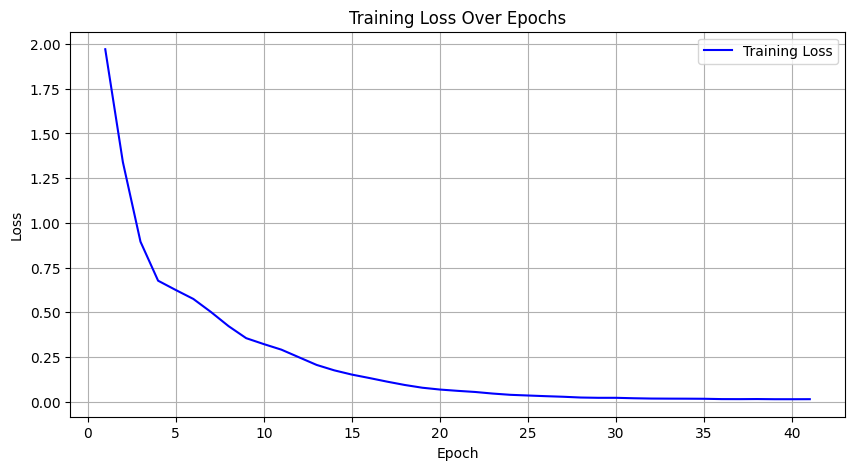

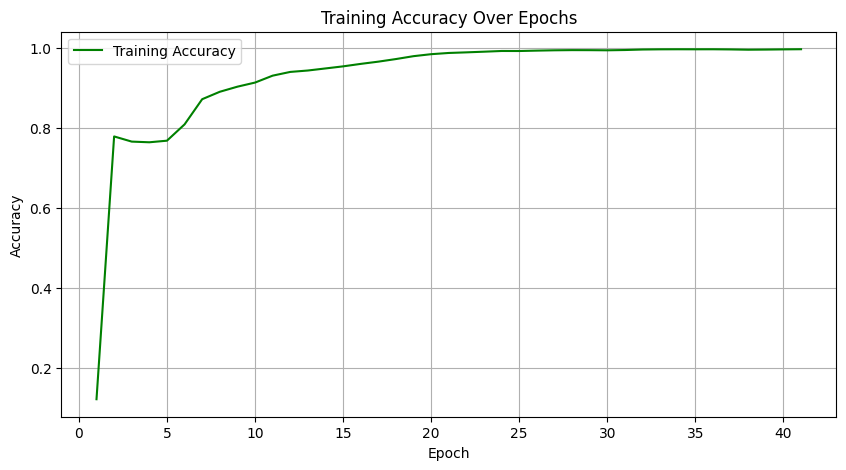

In [40]:
# Plot Training Loss
plt.figure(figsize=(10, 5)) 
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()